<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/class_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler


In [ ]:
data= np.sin(np.linspace(0,100,1000))
data=data.reshape(-1,1)

In [ ]:
scaler=MinMaxScaler(feature_range=(0,1))
data_scaled=scaler.fit_transform(data)

In [ ]:
def creat_dataset(data,time_step=1):
  X,y=[],[]
  for i in range(len(data)- time_step -1):
    X.append(data[i:(i+time_step),0])
    y.append(data[i+ time_step,0])
  return np.array(X), np.array(y)

In [ ]:
time_step=10
X,y=creat_dataset(data_scaled, time_step)
X=X.reshape(X.shape[0], X.shape[1],1)
model=Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer="adam", loss="mean_squared_error")

In [ ]:
model.fit(X,y, epochs=100, batch_size=32)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1759
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0388
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0304
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0232
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0114
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.2328e-04
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.5965e-04
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.2018e-04
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3410e-04
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.4414e-04
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.0201e-05
Epoch 13/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.1069e-05
Epoch 14/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.9193e-05
Epoch 15/100
31/31 ━━━━━━━━━━━━━━━━━━

In [ ]:
predicted=model.predict(X)
predicted=scaler.inverse_transform(predicted)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


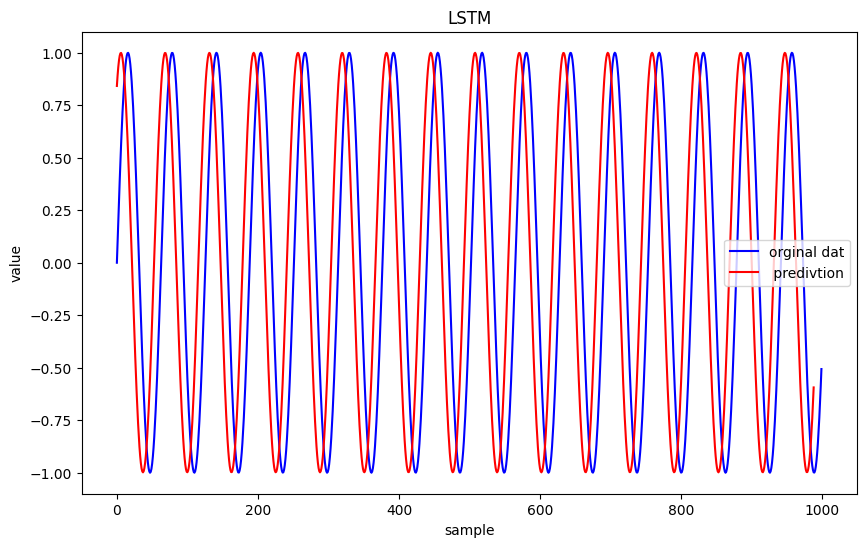

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(data,label='orginal dat', color="blue")
plt.plot(predicted, label=' predivtion', color="red")
plt.title('LSTM')
plt.xlabel('sample')
plt.ylabel('value')
plt.legend()
plt.show()

In [ ]:
last_sequence=data_scaled[-time_step:].reshape(1, time_step, 1)
next_prediction=model.predict(last_sequence)
next_prediction=scaler.inverse_transform(next_prediction)